# IEMS 490 Wave Training
Trains an open source version of Google's Wavenet architecture to fit our 'waves' from our LaserPowerCurrent and SignalPdInGaAs variables

In [1]:
import torch
from torch_fn.wavenet_lstm import lr_schedule, WaveNet_LSTM #LSTM of WaveNet
from torch_fn.wavenet2 import WaveNet # Normal WaveNet, likely from the paper. Need someone who is literate to check.
import h5py
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch.nn as nn
import torch.optim as optim

### For each time step in each file, get the Laser Power and Signal
We don't want to use X, Y because that can change in each layer

In [2]:
folder_path = './DATASET' # Replace with your folder path
# This creates a list of extensions (including the dot)
file_paths = [f for f in Path(folder_path).iterdir() if f.is_file() and f.suffix == '.hdf5']

print(file_paths)

[WindowsPath('DATASET/layer1.hdf5'), WindowsPath('DATASET/layer10.hdf5'), WindowsPath('DATASET/layer100.hdf5'), WindowsPath('DATASET/layer101.hdf5'), WindowsPath('DATASET/layer102.hdf5'), WindowsPath('DATASET/layer103.hdf5'), WindowsPath('DATASET/layer104.hdf5'), WindowsPath('DATASET/layer105.hdf5'), WindowsPath('DATASET/layer106.hdf5'), WindowsPath('DATASET/layer107.hdf5'), WindowsPath('DATASET/layer108.hdf5'), WindowsPath('DATASET/layer109.hdf5'), WindowsPath('DATASET/layer11.hdf5'), WindowsPath('DATASET/layer110.hdf5'), WindowsPath('DATASET/layer111.hdf5'), WindowsPath('DATASET/layer112.hdf5'), WindowsPath('DATASET/layer113.hdf5'), WindowsPath('DATASET/layer114.hdf5'), WindowsPath('DATASET/layer115.hdf5'), WindowsPath('DATASET/layer116.hdf5'), WindowsPath('DATASET/layer117.hdf5'), WindowsPath('DATASET/layer118.hdf5'), WindowsPath('DATASET/layer119.hdf5'), WindowsPath('DATASET/layer12.hdf5'), WindowsPath('DATASET/layer120.hdf5'), WindowsPath('DATASET/layer121.hdf5'), WindowsPath('DAT

In [3]:
file1 = h5py.File(file_paths[0], 'r')
file1

<HDF5 file "layer1.hdf5" (mode r)>

In [4]:
xs, ys = file1['OpenData'][0], file1['OpenData'][1]
x_dict, y_dict = {}, {}
n=1
for i in range(len(xs)):
    if round(xs[i],n) not in x_dict.keys():
        x_dict[round(xs[i],n)] = 1
    else:
        x_dict[round(xs[i],n)] += 1
    if round(ys[i],n) not in y_dict.keys():
        y_dict[round(ys[i],n)] = 1
    else:
        y_dict[round(ys[i],n)] += 1
vals = []
for x_val in x_dict.keys():
    vals.append(x_dict[x_val])
print(len(vals))
vals = []
for y_val in y_dict.keys():
    vals.append(y_dict[y_val])
print(len(vals))

94
94


In [5]:
coords = []
for x in x_dict.keys():
    for y in y_dict.keys():
        # Set as tuples rather than lists because we don't need to alter afterwards
        coords.append((x,y))

#### Will take a long time (sad) [maybe 5 minutes]
Will save this as an .npz file bc we're not doing this again unless we're changing the coordinates

In [6]:
#data = []
lazer_data, signal_data = [], []
bulk, overhang, c1, c2 = [], [], [],[]
for file in file_paths:
    file_info = h5py.File(file, 'r')
    file_data = file_info['OpenData']
    xs, ys, lazer, signal = file_data[0], file_data[1], file_data[5], file_data[6]
    b, o, c1_val, c2_val = file_data[7][0], file_data[8][0], file_data[9][0], file_data[10][0]
    file_info.close()
    #x_dict, y_dict= {}, {}
    lazer_dict, signal_dict = {}, {}
    for i in range(len(xs)):
        new_coords = (round(xs[i], 1), round(ys[i],1))
        if new_coords not in lazer_dict.keys():
            lazer_dict[new_coords] = [lazer[i]]
            signal_dict[new_coords] = [signal[i]]
        else:
            lazer_dict[new_coords].append(lazer[i])
            #lazer_dict[new_coords][1]+=1
            signal_dict[new_coords].append(signal[i])
            #signal_dict[new_coords][1]+=1
    lazer_data.append(lazer_dict)
    signal_data.append(signal_dict)
    bulk.append(b)
    overhang.append(o)
    c1.append(c1_val)
    c2.append(c2_val)

In [7]:
median_lazer = []
median_signal = []
for i in range(len(lazer_data)):
    l_dict, s_dict = lazer_data[i], signal_data[i]
    
    # Process all coordinates for this file in one go
    batch_l = [np.median(l_dict[c]) if c in l_dict else 0 for c in coords]
    batch_s = [np.median(s_dict[c]) if c in s_dict else 0 for c in coords]
    
    median_lazer.append(batch_l)
    median_signal.append(batch_s)

In [8]:
val_stack = np.stack(arrays=[bulk, overhang, c1, c2], axis=0)
val_stack.shape

(4, 379)

In [9]:
np.savez('my_arrays.npz', arr_a=np.array(median_lazer), arr_b=np.array(median_signal))
np.savez('val_arrays.npz', a=bulk, b=overhang, c=c1, d=c2)

### All data should now be the same length

In [2]:
# Load the data from the .npz file
npz_file = np.load('my_arrays.npz')

# Access individual arrays
median_lazer = npz_file['arr_a']
median_signal = npz_file['arr_b']

# Optional: check the names of all arrays in the file
print(f"Arrays in file: {npz_file.files}")

# Close the NpzFile object
npz_file.close()


Arrays in file: ['arr_a', 'arr_b']


In [3]:
median_lazer.shape

(379, 8836)

In [4]:
# 1. Combine lists into a single NumPy array (Shape: N x 2)
# This is significantly faster than a list comprehension for large data
all_data = np.stack([median_lazer, median_signal], axis=1)

# 2. Split the NumPy array directly
train_x, test_x = train_test_split(all_data, test_size=0.6, shuffle=False, random_state=67) # Sik Sewen

# 3. Convert directly to Tensors
# .float() ensures they are float32, which most PyTorch models expect
x_train_tensor = torch.from_numpy(train_x).float()
x_test_tensor  = torch.from_numpy(test_x).float()
print(f"Train Tensor Shape: {x_train_tensor.shape}")
print(f"Test Tensor Shape:  {x_test_tensor.shape}")

# 4. Create Dataset and Loader
# Using (x, x) for Autoencoder style or self-supervised training
train_dataset = TensorDataset(x_train_tensor, x_train_tensor)
test_dataset  = TensorDataset(x_test_tensor, x_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train Tensor Shape: torch.Size([151, 2, 8836])
Test Tensor Shape:  torch.Size([228, 2, 8836])


In [5]:
for batch, _ in train_loader:
    print(batch.shape)

torch.Size([32, 2, 8836])
torch.Size([32, 2, 8836])
torch.Size([32, 2, 8836])
torch.Size([32, 2, 8836])
torch.Size([23, 2, 8836])


### Train model

In [6]:
def train(model, dataloader, valid_dataloader, epochs = 10, lr=1e-3):
    #model.train()
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    train_losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch, _ in dataloader:
            outputs = model(batch)
            optimizer.zero_grad()
            loss = criterion(outputs, batch)
            loss.backward()
            optimizer.step()
            train_loss+= loss.item() * batch.size(0)
        epoch_loss = train_loss / len(dataloader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")
        train_losses.append(train_loss)
        valid_losses.append(test(model, valid_dataloader))
    return train_losses, valid_losses

def test(model, dataloader):
    model.eval()
    test_loss = 0
    criterion = nn.MSELoss()
    with torch.no_grad():
       for batch, _ in dataloader:
          #batch = batch.permute(0,2,1).float()
          outputs = model(batch)
          loss = criterion(batch, outputs)
          test_loss += loss.item() * batch.size(0)
    print(f"Test loss: {test_loss:.4f}")
    return test_loss


In [7]:
from torch_fn.wavenet2 import WaveNet
wave_model = WaveNet(input_size=2, out_channels=32, kernel_size=3, n=1)
train_loss, valid_loss = train(wave_model, train_loader, test_loader, epochs = 250)

Epoch [1/250], Loss: 6491640.3046
Test loss: 1481323376.0000
Epoch [2/250], Loss: 6491425.7517
Test loss: 1481269176.0000
Epoch [3/250], Loss: 6491150.0993
Test loss: 1481185934.0000
Epoch [4/250], Loss: 6490681.7185
Test loss: 1481029274.0000
Epoch [5/250], Loss: 6489824.8477
Test loss: 1480757682.0000
Epoch [6/250], Loss: 6488402.6523
Test loss: 1480342760.0000
Epoch [7/250], Loss: 6486353.6788
Test loss: 1479774056.0000
Epoch [8/250], Loss: 6483603.6391
Test loss: 1479060202.0000
Epoch [9/250], Loss: 6480178.6424
Test loss: 1478176116.0000
Epoch [10/250], Loss: 6476052.3675
Test loss: 1477112522.0000
Epoch [11/250], Loss: 6470944.7351
Test loss: 1475787990.0000
Epoch [12/250], Loss: 6464706.0397
Test loss: 1474175540.0000
Epoch [13/250], Loss: 6457158.0331
Test loss: 1472238274.0000
Epoch [14/250], Loss: 6447986.1656
Test loss: 1469939696.0000
Epoch [15/250], Loss: 6437308.5331
Test loss: 1467232782.0000
Epoch [16/250], Loss: 6424737.9272
Test loss: 1464082080.0000
Epoch [17/250], L

Note to self: Seems better, we went from test loss of 3 million to 1.5 million. Should've split test into valid and test... oh well

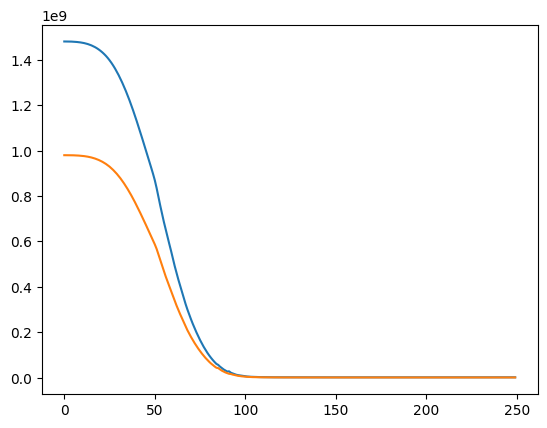

In [8]:
import matplotlib.pyplot as plt
plt.plot(valid_loss)
plt.plot(train_loss)
plt.show()

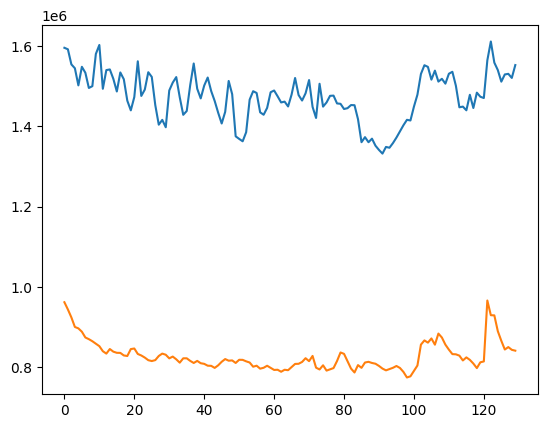

In [10]:
plt.plot(valid_loss[120:])
plt.plot(train_loss[120:])
plt.show()

In [11]:
PATH = "model_weights2.pth"
torch.save(wave_model.state_dict(), PATH)

In [12]:
for batch, _ in test_loader:
    results = wave_model(batch)
    print(results)

tensor([[[4.2549e+03, 4.4966e+03, 4.5086e+03,  ..., 2.0213e+03,
          9.8077e-02, 3.7270e+03],
         [1.4360e+03, 1.5175e+03, 1.5216e+03,  ..., 6.8215e+02,
          2.0322e-01, 1.2578e+03]],

        [[4.1477e+03, 0.0000e+00, 4.5146e+03,  ..., 1.2470e-01,
          0.0000e+00, 0.0000e+00],
         [1.3998e+03, 2.1763e-01, 1.5236e+03,  ..., 2.1355e-01,
          9.0251e+00, 4.0411e+00]],

        [[4.1302e+03, 4.4417e+03, 0.0000e+00,  ..., 4.4439e+03,
          0.0000e+00, 0.0000e+00],
         [1.3939e+03, 1.4990e+03, 4.1732e-01,  ..., 1.4998e+03,
          1.3315e+00, 7.2307e+00]],

        ...,

        [[4.1477e+03, 0.0000e+00, 4.5151e+03,  ..., 9.8077e-02,
          4.2554e+03, 1.3082e+02],
         [1.3998e+03, 2.1742e-01, 1.5238e+03,  ..., 2.0322e-01,
          1.4361e+03, 4.4141e+01]],

        [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 2.2796e-02, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 2

In [18]:
zeros = 0
for result in results[0][0]:
    if result.item() == 0:
        zeros+=1
print(len(results[0][0]))
print(zeros)
results[0][0]

8836
3430


tensor([3862.7952,    0.0000,    0.0000,  ...,    0.0000,    0.0000,
           0.0000], grad_fn=<SelectBackward0>)

### We might be able to train BERT like encoder to fill in the blanks